#### Dataset
- Name: Titanic Dataset
- Task: Binary Classification
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> Random Forest 🌲🌲🌲

**In this notebook, we first implement RF manually—from scratch—and then compare it with a ready-made model from a library.**

The main difference between a Random Forest and a standard Decision Tree is that, in a standard tree, all features are evaluated at each split to select the best one.

In a Random Forest, however, each tree considers only a subset of the features. This ensures that the trees are not identical.

If we were to build 100 decision trees that all used the exact same features, they would likely all make the same errors; but if each tree differs slightly, combining them leads to better generalization.

In Random Forest, we construct a new internal decision tree that possesses only the features required for Random Forest:

max_features</br>
bootstrap sampling</br>
multiple trees</br>
majority voting

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from src.random_forest import (
    RandomForest
)

<h3> Step 1: Dataset

In [2]:
df = pd.read_csv(
    "../../../datasets/Titanic-Dataset/processed/titanic_feature_engineered.csv"
)

df.head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


In [3]:
X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]

In [4]:
numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=[
        "object"
    ]
).columns.tolist()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
numeric_transformer = Pipeline(
    steps=[
        
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

<h3> Step 2: Building The Model

In [7]:
rf_model = RandomForest(
    n_estimators=10,
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    max_features=5
)

In [8]:
rf_model.fit(
    X_train_processed,
    y_train.values
)

In [9]:
y_pred_rf = rf_model.predict(
    X_test_processed
)

<h3> Step 3: Evaluate Random Forest

In [10]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

In [11]:
print(
    "Random Forest"
)

print(
    "Accuracy:",
    rf_accuracy
)

print(
    "Precision:",
    rf_precision
)

print(
    "Recall:",
    rf_recall
)

print(
    "F1-score:",
    rf_f1
)

print(
    "Confusion Matrix:"
)

print(
    rf_cm
)

Random Forest
Accuracy: 0.7877094972067039
Precision: 0.7627118644067796
Recall: 0.6521739130434783
F1-score: 0.703125
Confusion Matrix:
[[96 14]
 [24 45]]


### Comparison with Decision Tree

| Model                    | Accuracy | Precision | Recall | F1-score |
| ------------------------ | -------: | --------: | -----: | -------: |
| Decision Tree (Gini)     |   0.8212 |    0.7534 | 0.7971 |   0.7746 |
| Random Forest (10 Trees) |   0.7877 |    0.7627 | 0.6522 |   0.7031 |


Random Forest shines when:

There is a large number of samples</br>
There is a high level of noise</br>
A single Decision Tree suffers from overfitting

### Random Forest Evaluation

The initial Random Forest model was trained using 10 decision trees with feature randomness and bootstrap sampling.  
Although Random Forest is generally expected to reduce overfitting and improve generalization, the first experiment achieved lower performance than a single Decision Tree.  
This behavior can occur due to a small number of trees, dataset size, and hyperparameter choices.  
Further experiments will analyze the effect of the number of estimators, feature selection, and splitting criteria.

<h3> Step 4: Effect of Number of Trees (n_estimators)

Here, we want to see the effect of increasing the number of trees.

Parameter: `n_estimators`

This refers to the number of decision trees built in the forest.

In [12]:
n_estimators_values = [
    1,
    5,
    10,
    25,
    50,
    100
]

rf_results = []

for n_tree in n_estimators_values:
    print(
        f"Number of Trees: {n_tree}"
    )

    rf_model = RandomForest(
        n_estimators=n_tree,
        criterion="gini",
        max_depth=5,
        min_samples_split=10,
        max_features=5
    )

    rf_model.fit(
        X_train_processed,
        y_train.values
    )

    y_pred = rf_model.predict(
        X_test_processed
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    rf_results.append(
        [
            n_tree,
            accuracy,
            precision,
            recall,
            f1
        ]
    )

    print(
        "Accuracy:",
        accuracy
    )
    print(
        "F1:",
        f1
    )
    print("----------------")

Number of Trees: 1
Accuracy: 0.7486033519553073
F1: 0.697986577181208
----------------
Number of Trees: 5
Accuracy: 0.7988826815642458
F1: 0.7272727272727272
----------------
Number of Trees: 10
Accuracy: 0.7821229050279329
F1: 0.7022900763358778
----------------
Number of Trees: 25
Accuracy: 0.8044692737430168
F1: 0.732824427480916
----------------
Number of Trees: 50
Accuracy: 0.8268156424581006
F1: 0.7703703703703704
----------------
Number of Trees: 100
Accuracy: 0.8268156424581006
F1: 0.7669172932330827
----------------


In [13]:
rf_results_df = pd.DataFrame(
    rf_results,
    columns=[
        "Number of Trees",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

rf_results_df

,Number of Trees,Accuracy,Precision,Recall,F1-score
0,1,0.748603,0.650000,0.753623,0.697987
1,5,0.798883,0.761905,0.695652,0.727273
2,10,0.782123,0.741935,0.666667,0.702290
3,25,0.804469,0.774194,0.695652,0.732824
4,50,0.826816,0.787879,0.753623,0.770370
5,100,0.826816,0.796875,0.739130,0.766917


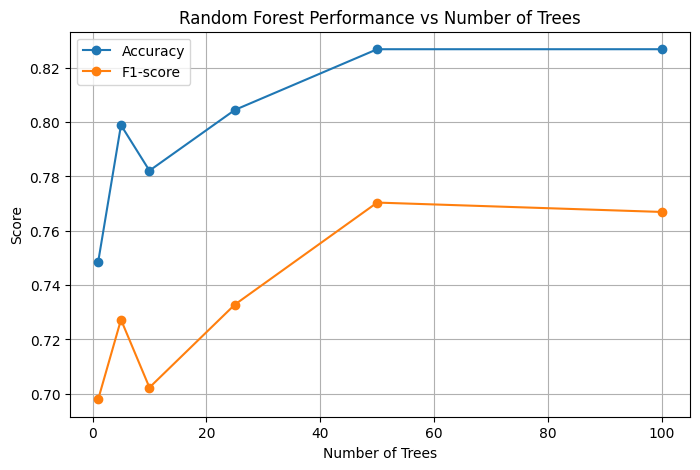

In [16]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    rf_results_df["Number of Trees"],
    rf_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_results_df["Number of Trees"],
    rf_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel(
    "Number of Trees"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Random Forest Performance vs Number of Trees"
)

plt.grid()
plt.legend()
plt.show()

### Effect of Number of Trees

The number of estimators was evaluated to study its impact on Random Forest performance.

Increasing the number of trees improved the model performance by reducing variance and combining multiple decision boundaries. The accuracy increased from 74.86% with a single tree to approximately 82.68% with 50 trees.

After around 50 estimators, the performance became stable, showing that adding more trees provides limited improvement while increasing computational cost.

<h3> Step 5: Effect of max_features

In [17]:
n_estimators=50

max_features_values = [
    5,
    14,
    None
]

max_features_results = []

for max_feature_value in max_features_values:
    print(
        f"Max Features: {max_feature_value}"
    )

    rf_model = RandomForest(
        n_estimators=50,
        criterion="gini",
        max_depth=5,
        min_samples_split=10,
        max_features=max_feature_value
    )

    rf_model.fit(
        X_train_processed,
        y_train.values
    )

    y_pred = rf_model.predict(
        X_test_processed
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    max_features_results.append(
        [
            str(max_feature_value),
            accuracy,
            precision,
            recall,
            f1
        ]
    )

    print(
        "Accuracy:",
        accuracy
    )
    print(
        "F1:",
        f1
    )
    print("----------------")

Max Features: 5
Accuracy: 0.8268156424581006
F1: 0.7669172932330827
----------------
Max Features: 14
Accuracy: 0.8156424581005587
F1: 0.759124087591241
----------------
Max Features: None
Accuracy: 0.8212290502793296
F1: 0.7746478873239437
----------------


In [18]:
max_features_df = pd.DataFrame(
    max_features_results,
    columns=[
        "Max Features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

max_features_df

,Max Features,Accuracy,Precision,Recall,F1-score
0,5,0.826816,0.796875,0.739130,0.766917
1,14,0.815642,0.764706,0.753623,0.759124
2,None,0.821229,0.753425,0.797101,0.774648


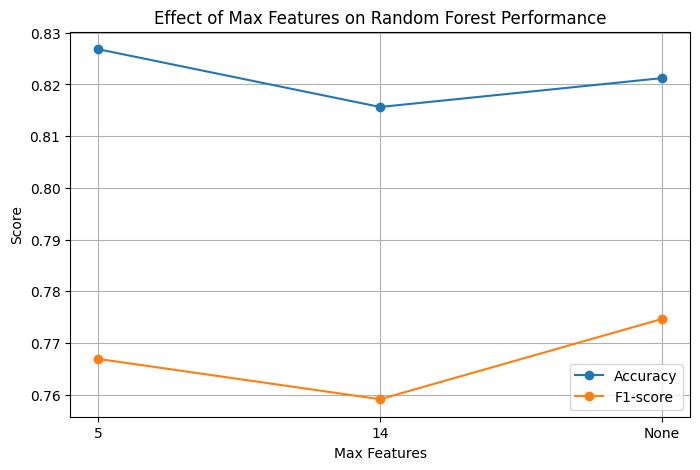

In [19]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    max_features_df["Max Features"],
    max_features_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    max_features_df["Max Features"],
    max_features_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel(
    "Max Features"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Effect of Max Features on Random Forest Performance"
)

plt.grid()
plt.legend()
plt.show()

### Effect of Max Features

The effect of feature randomness was evaluated by changing the number of features considered at each split.

Using a smaller number of features (`max_features=5`) achieved the highest accuracy (82.68%), showing that increasing randomness between trees can improve ensemble performance.

Using all features (`max_features=None`) produced a slightly lower accuracy but achieved higher recall and F1-score, demonstrating the trade-off between tree diversity and individual tree strength.

<h3> Step 6: Custom Random Forest vs Scikit-Learn RandomForestClassifier

In [ ]:
n_estimators = 50
max_depth = 5
min_samples_split = 10
max_features = 5
criterion = "gini"

In [21]:
custom_rf = RandomForest(
    n_estimators=50,
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    max_features=5
)

custom_rf.fit(
    X_train_processed,
    y_train.values
)

y_pred_custom_rf = custom_rf.predict(
    X_test_processed
)


custom_rf_accuracy = accuracy_score(
    y_test,
    y_pred_custom_rf
)
custom_rf_precision = precision_score(
    y_test,
    y_pred_custom_rf
)
custom_rf_recall = recall_score(
    y_test,
    y_pred_custom_rf
)
custom_rf_f1 = f1_score(
    y_test,
    y_pred_custom_rf
)
custom_rf_cm = confusion_matrix(
    y_test,
    y_pred_custom_rf
)

In [22]:
sklearn_rf = RandomForestClassifier(
    n_estimators=50,
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    max_features=5,
    random_state=42
)

sklearn_rf.fit(
    X_train_processed,
    y_train
)

y_pred_sklearn_rf = sklearn_rf.predict(
    X_test_processed
)


sklearn_rf_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn_rf
)
sklearn_rf_precision = precision_score(
    y_test,
    y_pred_sklearn_rf
)
sklearn_rf_recall = recall_score(
    y_test,
    y_pred_sklearn_rf
)
sklearn_rf_f1 = f1_score(
    y_test,
    y_pred_sklearn_rf
)
sklearn_rf_cm = confusion_matrix(
    y_test,
    y_pred_sklearn_rf
)

In [23]:
rf_comparison = pd.DataFrame(
    {
        "Model":[
            "Custom Random Forest",
            "Scikit-Learn Random Forest"
        ],
        "Accuracy":[
            custom_rf_accuracy,
            sklearn_rf_accuracy
        ],
        "Precision":[
            custom_rf_precision,
            sklearn_rf_precision
        ],
        "Recall":[
            custom_rf_recall,
            sklearn_rf_recall
        ],
        "F1-score":[
            custom_rf_f1,
            sklearn_rf_f1
        ],
        "Confusion Matrix":[
            custom_rf_cm.tolist(),
            sklearn_rf_cm.tolist()
        ]
    }
)

rf_comparison

,Model,Accuracy,Precision,Recall,F1-score,Confusion Matrix
0,Custom Random Forest,0.832402,0.809524,0.739130,0.772727,"[[98, 12], [18, 51]]"
1,Scikit-Learn Random Forest,0.821229,0.776119,0.753623,0.764706,"[[95, 15], [17, 52]]"


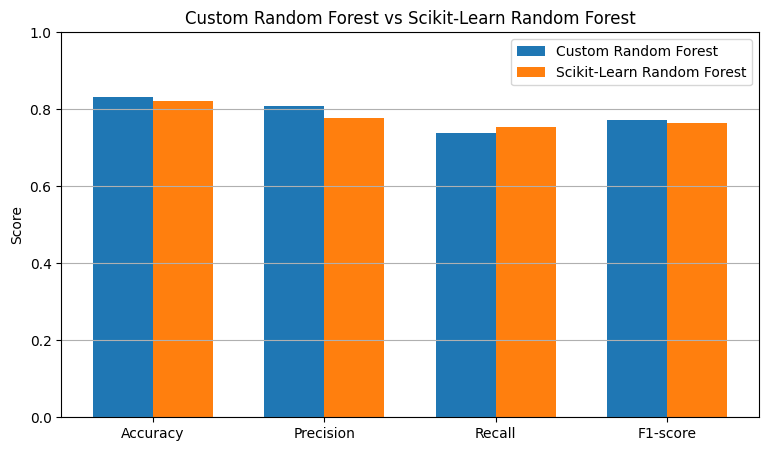

In [24]:
comparison_plot = rf_comparison.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

custom_values = comparison_plot.iloc[0][metrics]
sklearn_values = comparison_plot.iloc[1][metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(
    figsize=(9,5)
)
plt.bar(
    x - width/2,
    custom_values,
    width,
    label="Custom Random Forest"
)
plt.bar(
    x + width/2,
    sklearn_values,
    width,
    label="Scikit-Learn Random Forest"
)
plt.xticks(
    x,
    metrics
)
plt.ylabel(
    "Score"
)
plt.title(
    "Custom Random Forest vs Scikit-Learn Random Forest"
)
plt.ylim(
    0,
    1
)
plt.grid(
    axis="y"
)
plt.legend()
plt.show()

### Comparison with Scikit-Learn Random Forest

To validate the custom implementation, the developed Random Forest model was compared with Scikit-Learn's `RandomForestClassifier`.

Both models were trained using the same dataset, preprocessing pipeline, and similar hyperparameters:

- Number of estimators: 50
- Criterion: Gini impurity
- Maximum depth: 5
- Minimum samples split: 10
- Maximum features per split: 5

The results are shown below:

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Custom Random Forest | 0.8324 | 0.8095 | 0.7391 | 0.7727 |
| Scikit-Learn Random Forest | 0.8212 | 0.7761 | 0.7536 | 0.7647 |

The custom implementation achieved slightly higher accuracy, precision, and F1-score, while Scikit-Learn achieved a slightly higher recall.

The small difference between the two implementations is expected because Random Forest is a stochastic algorithm. Bootstrap sampling and random feature selection introduce randomness during training, which can lead to slightly different decision boundaries.

The close performance between the two models demonstrates that the core components of the custom implementation were correctly implemented, including:

- Bootstrap sampling
- Training multiple decision trees
- Random feature selection
- Majority voting for classification

Although Scikit-Learn provides a highly optimized implementation with additional performance improvements, building Random Forest from scratch provided a deeper understanding of the internal mechanisms behind ensemble learning.